# Adaptive Exploration: UCB Algorithm

## 📚 Learning Objectives

By completing this notebook, you will:
- Use UCB and adaptive exploration
- Apply to bandits and simple MDPs

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 4**.

---


## Lesson Brief

This lesson introduces **Upper Confidence Bound (UCB)** style exploration.

Students will see how uncertainty itself can be used to guide action choice, rather than relying only on random exploration.

Why this matters: UCB helps students understand that exploration can be principled, not only stochastic.

It is an important contrast to epsilon-greedy.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **ritvikmath - "Best Multi-Armed Bandit Strategy? (feat: UCB Method)"**:
[Watch on YouTube](https://www.youtube.com/watch?v=FgmMK6RPU1c)

Why this pick:
- intuitive explanation of the UCB formula.
- Shows how uncertainty bonuses drive smarter exploration than plain epsilon-greedy.
- Very good match for adaptive exploration in bandit-style settings.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: loss from not always choosing the best action.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.


# Adaptive Exploration: UCB Algorithm
## AIAT 123 - Reinforcement Learning

---

## Learning Objectives

This notebook demonstrates key concepts through hands-on examples.

By completing this notebook, you will:
- Understand Upper Confidence Bound (UCB) algorithm
- Implement UCB for multi-armed bandit problem
- Compare UCB with epsilon-greedy
- Apply UCB to real-world scenarios

---

## Prerequisites

- ✅ Python 3.8+ installed
- ✅ Required libraries (see `requirements.txt`)
- ✅ Basic Python knowledge

---

## Real-World Context

You are optimizing an online advertising campaign using UCB to balance exploring new ad variants and exploiting known high-performing ads.

---


## UCB Algorithm

Implement Upper Confidence Bound algorithm.


## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt



## 🌍 Real-World Worked Example — A/B Testing with Multi-Armed Bandits

**Industry context:**
- UCB is often easiest to explain first in bandit settings because uncertainty is isolated clearly
- Full MDP exploration is more complex than this notebook and is intentionally deferred
- This worked example is a bandit case study, not a full MDP benchmark

We compare **ε-greedy**, **UCB**, and **Thompson Sampling** on a real A/B test simulation.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


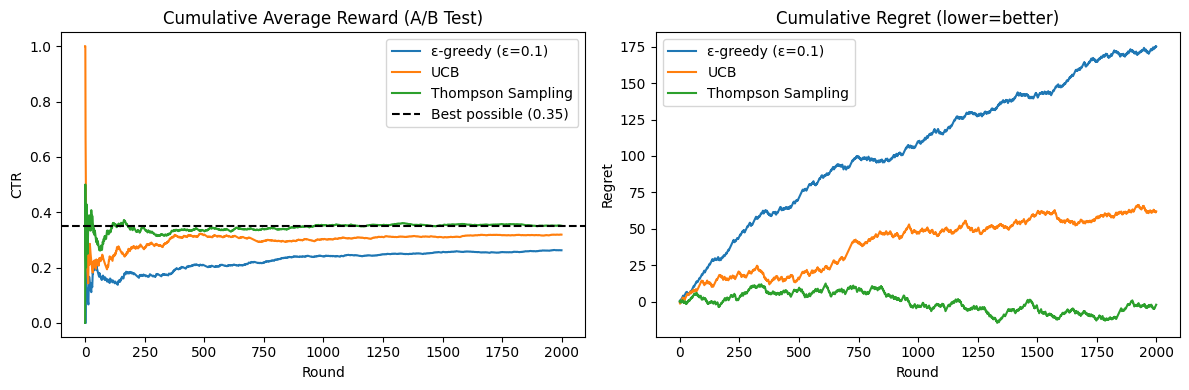


Total rewards — ε-greedy: 525, UCB: 638, Thompson: 702


In [2]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np, matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# ── Scenario: 5 website variants (like Netflix thumbnails)
# True click-through rates (unknown to agent)
# Save a value in a name so the next lines can read it.
TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]   # Variant 3 is best (35%)
# Another assignment—same idea: store a value for the lines below.
N_ARMS   = len(TRUE_RATES)
# Another assignment—same idea: store a value for the lines below.
N_ROUNDS = 2000

# Function `pull` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: arm.
def pull(arm): return 1 if np.random.rand() < TRUE_RATES[arm] else 0

# Function `epsilon_greedy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: eps.
def epsilon_greedy(eps):
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        arm = np.random.randint(N_ARMS) if np.random.rand()<eps else np.argmax(totals/(counts+1e-9))
        # Add one new item to the end of a list (the list grows in place).
        r = pull(arm); counts[arm]+=1; totals[arm]+=r; rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Function `ucb` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def ucb():
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for arm in range(N_ARMS): r=pull(arm); counts[arm]=1; totals[arm]+=r; rewards.append(r)
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(N_ARMS, N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        ucb_vals = totals/counts + np.sqrt(2*np.log(t+1)/counts)
        # Another assignment—same idea: store a value for the lines below.
        arm = np.argmax(ucb_vals)
        # Add one new item to the end of a list (the list grows in place).
        r = pull(arm); counts[arm]+=1; totals[arm]+=r; rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Function `thompson` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def thompson():
    # Save a value in a name so the next lines can read it.
    alpha = np.ones(N_ARMS); beta_ = np.ones(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        samples = np.random.beta(alpha, beta_)
        # Another assignment—same idea: store a value for the lines below.
        arm = np.argmax(samples)
        # Another assignment—same idea: store a value for the lines below.
        r = pull(arm)
        # If the condition is True, run the indented block under this line.
        if r: alpha[arm]+=1
        # Else: run this block when none of the if/elif tests above matched.
        else: beta_[arm]+=1
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Save a value in a name so the next lines can read it.
strategies = {
    # Another assignment—same idea: store a value for the lines below.
    'ε-greedy (ε=0.1)': epsilon_greedy(0.1),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'UCB':               ucb(),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'Thompson Sampling': thompson(),
# Part of a dict/set literal layout (syntax grouping).
}

# Function `cumavg` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: lst.
def cumavg(lst): return np.cumsum(lst) / np.arange(1,len(lst)+1)

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(12,4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1,2,1)
# Start a loop: repeat the indented block once per item in the sequence.
for name, r in strategies.items():
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(cumavg(r), label=name)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(max(TRUE_RATES), color='k', linestyle='--', label=f"Best possible ({max(TRUE_RATES)})")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Cumulative Average Reward (A/B Test)"); plt.xlabel("Round"); plt.ylabel("CTR"); plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1,2,2)
# Start a loop: repeat the indented block once per item in the sequence.
for name, r in strategies.items():
    # Save a value in a name so the next lines can read it.
    regret = np.cumsum([max(TRUE_RATES)-pull(np.argmax(TRUE_RATES)) for _ in r]) - np.cumsum(r) + np.cumsum([pull(np.argmax(TRUE_RATES)) for _ in r])
    # Another assignment—same idea: store a value for the lines below.
    regret_simple = np.cumsum(max(TRUE_RATES) - np.array(r))
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(regret_simple, label=name)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Cumulative Regret (lower=better)"); plt.xlabel("Round"); plt.ylabel("Regret"); plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout(); plt.show()
# Show text or numbers in the cell output area under the code.
print(f"\nTotal rewards — ε-greedy: {sum(strategies['ε-greedy (ε=0.1)'])}, UCB: {sum(strategies['UCB'])}, Thompson: {sum(strategies['Thompson Sampling'])}")


In [ ]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

### State-of-the-art ε-greedy and UCB are still dominant in industry A/B testing systems.
"""))


## 📝 Summary

You compared **exploration strategies**: ε-greedy (simple, effective), UCB (optimism under uncertainty), and Thompson Sampling (Bayesian). The exploration-exploitation tradeoff is central to RL. Real applications: A/B testing at Netflix, ad bidding at Google, recommendation engines at Spotify.

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


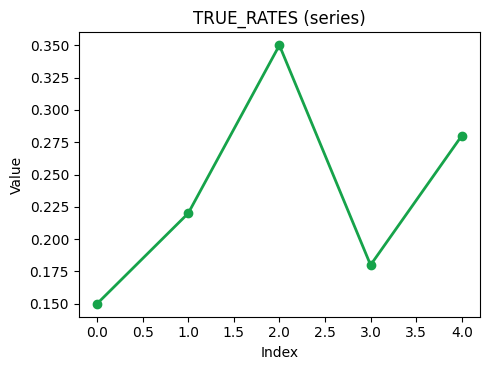

In [3]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** UCB explores based on uncertainty, giving extra attention to actions that may be promising but have not been tested enough.

**If students remember one idea:** Adaptive exploration uses what the agent has learned so far to decide where uncertainty is still worth paying for.

**Quick check before moving on:**
- Can you explain why UCB adds an uncertainty bonus to estimated value?
- Can you describe what happens to that bonus as an action is sampled more often?

**Bridge to the next step:** The next lesson compares multiple exploration methods so students can judge trade-offs more directly.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.


In [ ]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz


def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")
